<a href="https://colab.research.google.com/github/Devil-92/100_Days_of_ML/blob/main/Titanic_DataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Kaggle DataSet Setup

In [1]:
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

Mounted at /content/gdrive


In [2]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.1 MB/s eta 0:00:00


In [4]:
import kaggle

print(kaggle.__version__)

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token
2.2.4


In [5]:
%cd /content/gdrive/MyDrive/Projects/Titanic/

/content/gdrive/MyDrive/Projects/Titanic


In [6]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content/gdrive/MyDrive/Projects/Titanic/"

In [7]:
!kaggle competitions download -c titanic

Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, generate an API token at
  https://www.kaggle.com/settings/api  (click "Generate New Token" under "API")
and supply it to the CLI in one of these ways:

  Option A: Environment variable
    export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx  # token copied from the settings UI

  Option B: API token file
    Save the token to ~/.kaggle/access_token
Authentication required to call the Kaggle API.

First, you will need a Kaggle account. You can sign up at
  https://www.kaggle.com/account/login

Recommended: log in with OAuth via a web-based authorization flow.
No token to manage; credentials are cached locally for you.
    kaggle auth login

If you'd rather not use OAuth, gener

In [8]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

In [9]:
train_df = pd.read_csv('/content/gdrive/MyDrive/Projects/Titanic/titanic_data/train.csv')
test_df = pd.read_csv('/content/gdrive/MyDrive/Projects/Titanic/titanic_data/test.csv')

In [10]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
print(train_df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [12]:
len(train_df)

891

In [13]:
len(test_df)

418

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [15]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [16]:
id = test_df['PassengerId']

In [17]:
def missing_percent(df):
  missing = df.isna().sum().sort_values(ascending = False)
  percent = round(missing / len(df) , 2)
  return pd.concat([missing , percent] , axis = 1 , keys = ['Total Missing' , 'Percent Missing'])

In [18]:
missing_percent(train_df)

,Total Missing,Percent Missing
Cabin,687,0.77
Age,177,0.20
Embarked,2,0.00
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [19]:
missing_percent(test_df)

,Total Missing,Percent Missing
Cabin,327,0.78
Age,86,0.21
Fare,1,0.00
Name,0,0.00
Pclass,0,0.00
PassengerId,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00
Ticket,0,0.00


In [20]:
def percent_value_counts(df , feature):
  percent = round(df.loc[: , feature].value_counts(dropna = False , normalize = True) * 100 , 2)
  total = df.loc[: , feature].value_counts(dropna = False)
  return pd.concat([percent , total] , axis = 1 , keys = ['Percent' , 'Total'])

In [21]:
def percent_value_counts(df , feature):
  return pd.DataFrame({
      'Percent' : round(df[feature].value_counts(dropna = False , normalize = True)*100 , 2) ,
      'Total' : df[feature].value_counts(dropna = False)
  })

In [22]:
print("Any of the both methods can be used")

Any of the both methods can be used


In [23]:
percent_value_counts(train_df , 'Embarked')

,Percent,Total
Embarked,,
S,72.28,644
C,18.86,168
Q,8.64,77
NaN,0.22,2


In [24]:
percent_value_counts(test_df , 'Embarked')

,Percent,Total
Embarked,,
S,64.59,270
C,24.40,102
Q,11.00,46


In [25]:
percent_value_counts(train_df , 'Sex')

,Percent,Total
Sex,,
male,64.76,577
female,35.24,314


In [26]:
train_df[train_df['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [27]:
train_df['Embarked'].fillna('S' , inplace = True)

In [28]:
train_df['Embarked'].value_counts(dropna = False)

,count
Embarked,
S,646
C,168
Q,77


In [29]:
print(f"Percent of missing Cabin values on Train : {round(train_df['Cabin'].isnull().sum()/len(train_df) * 100, 2)}")

Percent of missing Cabin values on Train : 77.1


In [30]:
print(f"Percent of missing Cabin values on Test : {round(test_df['Cabin'].isnull().sum()/len(test_df) * 100 , 2)}")

Percent of missing Cabin values on Test : 78.23


In [31]:
Survived = train_df['Survived']

train_df.drop(['Survived'] , axis = 1 , inplace = True)

all_data = pd.concat([train_df , test_df] , ignore_index = True)

all_data['Cabin'].fillna('N' , inplace = True)

In [32]:
all_data['Cabin'] = [i[0] for i in all_data['Cabin']]

In [33]:
percent_value_counts(all_data , 'Cabin')

,Percent,Total
Cabin,,
N,77.46,1014
C,7.18,94
B,4.97,65
D,3.51,46
E,3.13,41
A,1.68,22
F,1.60,21
G,0.38,5
T,0.08,1


In [34]:
all_data.groupby('Cabin')['Fare'].mean().sort_values()

,Fare
Cabin,
G,14.205000
F,18.079367
N,19.132707
T,35.500000
A,41.244314
D,53.007339
E,54.564634
C,107.926598
B,122.383078


In [35]:
def cabin_est(x):
  a = 0
  if x < 16 :
    a = 'G'
  elif x < 27 :
    a = 'F'
  elif x < 38 :
    a = 'T'
  elif x < 47 :
    a = 'A'
  elif x < 53 :
    a = 'D'
  elif x < 54 :
    a = 'E'
  elif x < 116 :
    a = 'C'
  else :
    a = 'B'
  return a

In [36]:
with_N = all_data[all_data['Cabin'] == 'N']
without_N = all_data[all_data['Cabin'] != 'N']

In [37]:
len(train_df)

891

In [38]:
len(test_df)

418

In [39]:
len(all_data)

1309

In [40]:
with_N['Cabin'] = with_N['Fare'].apply(lambda x : cabin_est(x))

all_data = pd.concat([with_N , without_N] , axis = 0)

all_data.sort_values(by = 'PassengerId' , inplace = True)

train_df = all_data[:891]
test_df = all_data[891:]

train_df['Survived'] = Survived

In [41]:
train_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,G,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,G,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,G,S,0


In [42]:
train_df.Cabin.value_counts()

,count
Cabin,
G,464
F,128
C,88
B,55
T,53
D,37
A,34
E,32


In [43]:
train_df['Fare'].isnull().sum()

np.int64(0)

In [44]:
test_df['Fare'].isnull().sum()

np.int64(1)

In [45]:
test_df[test_df['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,B,S


In [46]:
print('We will take the best missing guess for Fare by Pclass = 3 and Embarked = S and Sex = male')

We will take the best missing guess for Fare by Pclass = 3 and Embarked = S and Sex = male


In [47]:
missing_value = test_df[
    (test_df['Pclass'] == 3) &
    (test_df['Embarked'] == 'S') &
    (test_df['Sex'] == 'male')
]['Fare'].mean()

In [48]:
missing_value

np.float64(12.718872000000001)

In [49]:
test_df['Fare'].fillna(missing_value , inplace = True)

In [50]:
len(test_df)

418

In [51]:
print(f"Train data missing age percent {round(train_df['Age'].isnull().sum() / len(train_df) * 100 , 3)}")

Train data missing age percent 19.865


In [52]:
print(f"Test data missing age percent {round(test_df['Age'].isnull().sum()/len(test_df) * 100, 3)}")

Test data missing age percent 20.574


In [53]:
train_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.204208,0.383838
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693429,0.486592
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [54]:
train_df.describe(include = ['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,891
unique,891,2,681,8,3
top,"Dooley, Mr. Patrick",male,347082,G,S
freq,1,577,7,464,646


In [55]:
train_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,G,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,G,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,G,S,0


In [56]:
len(train_df.columns)

12

In [57]:
train_df['Sex'] = train_df['Sex'].apply(lambda x : 0 if x == 'female' else 1)
test_df['Sex'] = test_df['Sex'].apply(lambda x : 0 if x == 'female' else 1)

In [58]:
train_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,G,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,C,1
2,3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,G,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,S,1
4,5,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,G,S,0


In [59]:
train_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked', 'Survived'],
      dtype='object')

In [60]:
test_df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [61]:
len(train_df.columns)

12

In [62]:
len(test_df)

418

In [63]:
survived_summary = train_df.groupby('Survived').mean(numeric_only = True).reset_index()

In [64]:
survived_summary

,Survived,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,447.016393,2.531876,0.852459,30.626179,0.553734,0.329690,22.117887
1,1,444.368421,1.950292,0.318713,28.343690,0.473684,0.464912,48.395408


In [65]:
survived_summary = train_df.groupby('Sex').mean(numeric_only = True).reset_index()

In [66]:
survived_summary

,Sex,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
0,0,431.028662,2.159236,27.915709,0.694268,0.649682,44.479818,0.742038
1,1,454.147314,2.389948,30.726645,0.429809,0.235702,25.523893,0.188908


In [67]:
survived_summary = train_df.groupby('Pclass').mean(numeric_only = True).reset_index()

In [68]:
survived_summary

,Pclass,PassengerId,Sex,Age,SibSp,Parch,Fare,Survived
0,1,461.597222,0.564815,38.233441,0.416667,0.356481,84.154687,0.629630
1,2,445.956522,0.586957,29.877630,0.402174,0.380435,20.662183,0.472826
2,3,439.154786,0.706721,25.140620,0.615071,0.393075,13.675550,0.242363


### Correlations

In [69]:
pd.DataFrame(abs(train_df.corr(numeric_only = True)['Survived']).sort_values(ascending = False))

,Survived
Survived,1.000000
Sex,0.543351
Pclass,0.338481
Fare,0.257307
Parch,0.081629
Age,0.077221
SibSp,0.035322
PassengerId,0.005007


In [70]:
train_df['name_length'] = [len(i) for i in train_df['Name']]
test_df['name_length'] = [len(i) for i in test_df['Name']]

In [71]:
train_df['name_length']

,name_length
0,23
1,51
2,22
3,44
4,24
...,...
886,21
887,28
888,40
889,21


In [72]:
def name_len_group(s):
  a = ''
  if s <= 20 :
    a = 'short'
  elif s <= 35 :
    a = 'medium'
  elif s <= 45 :
    a = 'good'
  else :
    a = 'long'
  return a

In [73]:
train_df['nLength_group'] = train_df['name_length'].map(name_len_group)
test_df['nLength_group'] = test_df['name_length'].map(name_len_group)

In [74]:
train_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,name_length,nLength_group
0,1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,G,S,0,23,medium
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,C,1,51,long
2,3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,G,S,1,22,medium
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,S,1,44,good
4,5,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,G,S,0,24,medium


In [75]:
group_names = ['short' , 'medium' , 'good' , 'long']
train_df['name_len_group'] = pd.qcut(train_df['name_length'] , q = 4 , labels = group_names)

In [76]:
group_names = ['short' , 'medium' , 'good' , 'long']
test_df['name_len_group'] = pd.qcut(test_df['name_length'] , q = 4 , labels = group_names)

In [77]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_length,nLength_group,name_len_group
891,892,3,"Kelly, Mr. James",1,34.5,0,0,330911,7.8292,G,Q,16,short,short
892,893,3,"Wilkes, Mrs. James (Ellen Needs)",0,47.0,1,0,363272,7.0000,G,S,32,medium,long
893,894,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,240276,9.6875,G,Q,25,medium,medium
894,895,3,"Wirz, Mr. Albert",1,27.0,0,0,315154,8.6625,G,S,16,short,short
895,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,3101298,12.2875,G,S,44,good,long


In [78]:
train_df["name_len_group"].value_counts()

,count
name_len_group,
short,243
long,222
medium,215
good,211


In [79]:
train_df.drop(['nLength_group'] , axis = 1 , inplace = True)

In [80]:
test_df.drop(['nLength_group'] , axis = 1 , inplace = True)

In [81]:
train_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,name_length,name_len_group
0,1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,G,S,0,23,medium
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,C,1,51,long
2,3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,G,S,1,22,medium
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,S,1,44,long
4,5,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,G,S,0,24,medium


In [82]:
train_df['title'] = [i.split('.')[0] for i in train_df['Name']]

In [83]:
train_df['title'] = [i.split(',')[1] for i in train_df['title']]

In [84]:
train_df['title'].unique()

array([' Mr', ' Mrs', ' Miss', ' Master', ' Don', ' Rev', ' Dr', ' Mme',
       ' Ms', ' Major', ' Lady', ' Sir', ' Mlle', ' Col', ' Capt',
       ' the Countess', ' Jonkheer'], dtype=object)

In [85]:
train_df['title'] = [i.strip() for i in train_df['title']]

In [86]:
train_df['title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'the Countess',
       'Jonkheer'], dtype=object)

In [87]:
train_df['title'].value_counts()

,count
title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [88]:
test_df['title'] = [i.split('.')[0].split(',')[1].strip() for i in test_df['Name']]

In [89]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,name_length,name_len_group,title
891,892,3,"Kelly, Mr. James",1,34.5,0,0,330911,7.8292,G,Q,16,short,Mr
892,893,3,"Wilkes, Mrs. James (Ellen Needs)",0,47.0,1,0,363272,7.0000,G,S,32,long,Mrs
893,894,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,240276,9.6875,G,Q,25,medium,Mr
894,895,3,"Wirz, Mr. Albert",1,27.0,0,0,315154,8.6625,G,S,16,short,Mr
895,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,3101298,12.2875,G,S,44,long,Mrs


In [90]:
def name_converter(feature):
  result = ''
  if feature in ['Don', 'Rev', 'Dr','Major', 'Lady', 'Sir', 'Col', 'Capt', 'the Countess','Jonkheer'] :
    result = 'rare'
  elif feature in ['Mrs' , 'Mlle']:
    result = 'Miss'
  elif feature == 'Mme' :
    result = 'Mrs'
  else :
    result = feature
  return result

In [91]:
train_df['title'] = train_df['title'].map(name_converter)
test_df['title'] = test_df['title'].map(name_converter)

In [92]:
train_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,name_length,name_len_group,title
0,1,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,G,S,0,23,medium,Mr
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,C,1,51,long,Miss
2,3,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,G,S,1,22,medium,Miss
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C,S,1,44,long,Miss
4,5,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,G,S,0,24,medium,Mr


In [93]:
train_df.title.unique()

array(['Mr', 'Miss', 'Master', 'rare', 'Mrs', 'Ms'], dtype=object)

In [94]:
len(test_df)

418

In [95]:
train_df['family_size'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['family_size'] = test_df['SibSp'] + test_df['Parch'] + 1

In [96]:
def family_group(feature):
  status = ''
  if feature == 1:
    status = 'loner'
  elif feature <= 4 :
    status = 'small'
  else :
    status = 'large'
  return status

In [97]:
train_df['family_group'] = train_df['family_size'].map(family_group)
test_df['family_group'] = test_df['family_size'].map(family_group)

In [98]:
train_df['isalone'] = [1 if i < 2 else 0 for i in train_df.family_size]
test_df['isalone'] = [1 if i < 2 else 0 for i in test_df.family_size]

In [99]:
train_df['Ticket'].nunique()

681

In [100]:
print('Ticket is best dropped as it is unique for all passengers')

Ticket is best dropped as it is unique for all passengers


In [101]:
train_df.drop(['Ticket'] , axis = 1 , inplace = True)
test_df.drop(['Ticket'] , axis = 1 , inplace = True)

In [102]:
train_df['Calculated_fare'] = train_df.Fare/train_df.family_size
test_df['Calculated_fare'] = test_df.Fare/test_df.family_size

In [103]:
group_name = ['very_low' , 'low' , 'mid' , 'high' , 'very_high']
train_df['fare_group'] = pd.qcut(train_df['Calculated_fare'] , q = 5 , labels = group_name)
test_df['fare_group'] = pd.qcut(test_df['Calculated_fare'] , q = 5 , labels = group_name)

In [104]:
train_df.drop(['PassengerId'] , axis = 1 , inplace = True)

In [105]:
test_df.drop(['PassengerId'] , axis = 1 , inplace = True)

In [106]:
train_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived,name_length,name_len_group,title,family_size,family_group,isalone,Calculated_fare,fare_group
0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,G,S,0,23,medium,Mr,2,small,0,3.62500,very_low
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,C,C,1,51,long,Miss,2,small,0,35.64165,very_high
2,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,G,S,1,22,medium,Miss,1,loner,1,7.92500,mid
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,C,S,1,44,long,Miss,2,small,0,26.55000,high
4,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,G,S,0,24,medium,Mr,1,loner,1,8.05000,mid


In [107]:
test_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,name_length,name_len_group,title,family_size,family_group,isalone,Calculated_fare,fare_group
891,3,"Kelly, Mr. James",1,34.5,0,0,7.8292,G,Q,16,short,Mr,1,loner,1,7.829200,low
892,3,"Wilkes, Mrs. James (Ellen Needs)",0,47.0,1,0,7.0000,G,S,32,long,Miss,2,small,0,3.500000,very_low
893,2,"Myles, Mr. Thomas Francis",1,62.0,0,0,9.6875,G,Q,25,medium,Mr,1,loner,1,9.687500,mid
894,3,"Wirz, Mr. Albert",1,27.0,0,0,8.6625,G,S,16,short,Mr,1,loner,1,8.662500,mid
895,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",0,22.0,1,1,12.2875,G,S,44,long,Miss,3,small,0,4.095833,very_low


In [108]:
len(train_df.columns) -1 == len(test_df.columns)

True

In [109]:
len(test_df)

418

In [110]:
train_df = pd.get_dummies(train_df , columns = ['Pclass' , 'title' , 'Cabin' , 'Embarked' , 'name_len_group' , 'family_group' , 'fare_group'] , drop_first = False)

In [111]:
test_df = pd.get_dummies(test_df , columns = ['Pclass' , 'title' , 'Cabin' , 'Embarked' , 'name_len_group' , 'family_group' , 'fare_group'] , drop_first = False)

In [112]:
train_df.drop(['family_size' , 'Name' , 'Fare' , 'name_length'] , axis = 1 , inplace = True)
test_df.drop(['family_size' , 'Name' , 'Fare' , 'name_length'] , axis = 1 , inplace = True)

In [113]:
train_df.head()

,Sex,Age,SibSp,Parch,Survived,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,...,name_len_group_good,name_len_group_long,family_group_large,family_group_loner,family_group_small,fare_group_very_low,fare_group_low,fare_group_mid,fare_group_high,fare_group_very_high
0,1,22.0,1,0,0,0,3.62500,False,False,True,...,False,False,False,False,True,True,False,False,False,False
1,0,38.0,1,0,1,0,35.64165,True,False,False,...,False,True,False,False,True,False,False,False,False,True
2,0,26.0,0,0,1,1,7.92500,False,False,True,...,False,False,False,True,False,False,False,True,False,False
3,0,35.0,1,0,1,0,26.55000,True,False,False,...,False,True,False,False,True,False,False,False,True,False
4,1,35.0,0,0,0,1,8.05000,False,False,True,...,False,False,False,True,False,False,False,True,False,False


In [114]:
train_df.values

array([[1, 22.0, 1, ..., False, False, False],
       [0, 38.0, 1, ..., False, False, True],
       [0, 26.0, 0, ..., True, False, False],
       ...,
       [0, nan, 1, ..., False, False, False],
       [1, 26.0, 0, ..., False, False, True],
       [1, 32.0, 0, ..., False, False, False]], dtype=object)

In [115]:
train_df = pd.concat([train_df[['Survived' , 'Age' , 'Sex' , 'SibSp' , 'Parch']] , train_df.loc[: , 'isalone':]] , axis = 1)
test_df = pd.concat([test_df[['Age' , 'Sex']] , test_df.loc[: , 'SibSp':]] , axis = 1)

In [116]:
train_df.head()

,Survived,Age,Sex,SibSp,Parch,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,...,name_len_group_good,name_len_group_long,family_group_large,family_group_loner,family_group_small,fare_group_very_low,fare_group_low,fare_group_mid,fare_group_high,fare_group_very_high
0,0,22.0,1,1,0,0,3.62500,False,False,True,...,False,False,False,False,True,True,False,False,False,False
1,1,38.0,0,1,0,0,35.64165,True,False,False,...,False,True,False,False,True,False,False,False,False,True
2,1,26.0,0,0,0,1,7.92500,False,False,True,...,False,False,False,True,False,False,False,True,False,False
3,1,35.0,0,1,0,0,26.55000,True,False,False,...,False,True,False,False,True,False,False,False,True,False
4,0,35.0,1,0,0,1,8.05000,False,False,True,...,False,False,False,True,False,False,False,True,False,False


In [117]:
test_df.columns

Index(['Age', 'Sex', 'SibSp', 'Parch', 'isalone', 'Calculated_fare',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'title_Dona', 'title_Master',
       'title_Miss', 'title_Mr', 'title_Ms', 'title_rare', 'Cabin_A',
       'Cabin_B', 'Cabin_C', 'Cabin_D', 'Cabin_E', 'Cabin_F', 'Cabin_G',
       'Cabin_T', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'name_len_group_short', 'name_len_group_medium', 'name_len_group_good',
       'name_len_group_long', 'family_group_large', 'family_group_loner',
       'family_group_small', 'fare_group_very_low', 'fare_group_low',
       'fare_group_mid', 'fare_group_high', 'fare_group_very_high'],
      dtype='object')

In [118]:
test_df.head()

,Age,Sex,SibSp,Parch,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,title_Dona,...,name_len_group_good,name_len_group_long,family_group_large,family_group_loner,family_group_small,fare_group_very_low,fare_group_low,fare_group_mid,fare_group_high,fare_group_very_high
891,34.5,1,0,0,1,7.829200,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
892,47.0,0,1,0,0,3.500000,False,False,True,False,...,False,True,False,False,True,True,False,False,False,False
893,62.0,1,0,0,1,9.687500,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
894,27.0,1,0,0,1,8.662500,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
895,22.0,0,1,1,0,4.095833,False,False,True,False,...,False,True,False,False,True,True,False,False,False,False


In [119]:
from sklearn.ensemble import RandomForestRegressor
def completing_age(df):
  age_df = df.loc[: , 'Age' :]

  temp_train = age_df.loc[age_df['Age'].notnull()]
  temp_test = age_df.loc[age_df['Age'].isnull()]

  y = temp_train['Age'].values
  x = temp_train.loc[: , 'Sex':].values

  rfr = RandomForestRegressor(n_estimators = 1500 , n_jobs =- 1)
  rfr.fit(x , y)

  predicted_age = rfr.predict(temp_test.loc[: , 'Sex':])

  df.loc[df['Age'].isnull() , 'Age'] = predicted_age
  return df

In [120]:
completing_age(train_df)
completing_age(test_df)

,Age,Sex,SibSp,Parch,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,title_Dona,...,name_len_group_good,name_len_group_long,family_group_large,family_group_loner,family_group_small,fare_group_very_low,fare_group_low,fare_group_mid,fare_group_high,fare_group_very_high
891,34.500000,1,0,0,1,7.829200,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
892,47.000000,0,1,0,0,3.500000,False,False,True,False,...,False,True,False,False,True,True,False,False,False,False
893,62.000000,1,0,0,1,9.687500,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
894,27.000000,1,0,0,1,8.662500,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
895,22.000000,0,1,1,0,4.095833,False,False,True,False,...,False,True,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,23.288162,1,0,0,1,8.050000,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False
1305,39.000000,0,0,0,1,108.900000,True,False,False,True,...,True,False,False,True,False,False,False,False,False,True
1306,38.500000,1,0,0,1,7.250000,False,False,True,False,...,True,False,False,True,False,False,True,False,False,False
1307,23.288162,1,0,0,1,8.050000,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False


In [121]:
train_df.notnull().sum()

,0
Survived,891
Age,891
Sex,891
SibSp,891
Parch,891
isalone,891
Calculated_fare,891
Pclass_1,891
Pclass_2,891
Pclass_3,891


In [122]:
group_names = []
for i in range(1 , 10) :
  s = f"age_g_{i}"
  group_names.append(s)

In [123]:
group_names

['age_g_1',
 'age_g_2',
 'age_g_3',
 'age_g_4',
 'age_g_5',
 'age_g_6',
 'age_g_7',
 'age_g_8',
 'age_g_9']

In [124]:
train_df['age_group'] = pd.qcut(train_df.Age , q = 9 , labels = group_names)

In [125]:
test_df['age_group'] = pd.qcut(test_df.Age , q = 9 , labels = group_names)

In [126]:
train_df.head()

,Survived,Age,Sex,SibSp,Parch,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,...,name_len_group_long,family_group_large,family_group_loner,family_group_small,fare_group_very_low,fare_group_low,fare_group_mid,fare_group_high,fare_group_very_high,age_group
0,0,22.0,1,1,0,0,3.62500,False,False,True,...,False,False,False,True,True,False,False,False,False,age_g_3
1,1,38.0,0,1,0,0,35.64165,True,False,False,...,True,False,False,True,False,False,False,False,True,age_g_7
2,1,26.0,0,0,0,1,7.92500,False,False,True,...,False,False,True,False,False,False,True,False,False,age_g_4
3,1,35.0,0,1,0,0,26.55000,True,False,False,...,True,False,False,True,False,False,False,True,False,age_g_7
4,0,35.0,1,0,0,1,8.05000,False,False,True,...,False,False,True,False,False,False,True,False,False,age_g_7


In [127]:
train_df = pd.get_dummies(train_df , columns = ['age_group'] , drop_first = True)
test_df = pd.get_dummies(test_df , columns = ['age_group'] , drop_first = True)

In [128]:
train_df.head()

,Survived,Age,Sex,SibSp,Parch,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,...,fare_group_high,fare_group_very_high,age_group_age_g_2,age_group_age_g_3,age_group_age_g_4,age_group_age_g_5,age_group_age_g_6,age_group_age_g_7,age_group_age_g_8,age_group_age_g_9
0,0,22.0,1,1,0,0,3.62500,False,False,True,...,False,False,False,True,False,False,False,False,False,False
1,1,38.0,0,1,0,0,35.64165,True,False,False,...,False,True,False,False,False,False,False,True,False,False
2,1,26.0,0,0,0,1,7.92500,False,False,True,...,False,False,False,False,True,False,False,False,False,False
3,1,35.0,0,1,0,0,26.55000,True,False,False,...,True,False,False,False,False,False,False,True,False,False
4,0,35.0,1,0,0,1,8.05000,False,False,True,...,False,False,False,False,False,False,False,True,False,False


In [129]:
len(test_df.columns)

46

In [130]:
len(train_df.columns)

47

In [131]:
X = train_df.drop(['Survived'] , axis = 1)
y = train_df["Survived"]

In [132]:
len(test_df)

418

In [133]:
from sklearn.model_selection import train_test_split
X_train , X_val , y_train , y_val = train_test_split(X , y , test_size = 0.33 , random_state = 42)

In [134]:
len(X_train)

596

In [135]:
len(X_val)

295

In [136]:
headers = X_train.columns

In [137]:
X_train.head()

,Age,Sex,SibSp,Parch,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,title_Master,...,fare_group_high,fare_group_very_high,age_group_age_g_2,age_group_age_g_3,age_group_age_g_4,age_group_age_g_5,age_group_age_g_6,age_group_age_g_7,age_group_age_g_8,age_group_age_g_9
6,54.000000,1,0,0,1,51.8625,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
718,28.077091,1,0,0,1,15.5000,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False
685,25.000000,1,1,2,0,10.3948,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
73,26.000000,1,1,0,0,7.2271,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
882,22.000000,0,0,0,1,10.5167,False,False,True,False,...,True,False,False,True,False,False,False,False,False,False


In [138]:
train_df.columns

Index(['Survived', 'Age', 'Sex', 'SibSp', 'Parch', 'isalone',
       'Calculated_fare', 'Pclass_1', 'Pclass_2', 'Pclass_3', 'title_Master',
       'title_Miss', 'title_Mr', 'title_Mrs', 'title_Ms', 'title_rare',
       'Cabin_A', 'Cabin_B', 'Cabin_C', 'Cabin_D', 'Cabin_E', 'Cabin_F',
       'Cabin_G', 'Cabin_T', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'name_len_group_short', 'name_len_group_medium', 'name_len_group_good',
       'name_len_group_long', 'family_group_large', 'family_group_loner',
       'family_group_small', 'fare_group_very_low', 'fare_group_low',
       'fare_group_mid', 'fare_group_high', 'fare_group_very_high',
       'age_group_age_g_2', 'age_group_age_g_3', 'age_group_age_g_4',
       'age_group_age_g_5', 'age_group_age_g_6', 'age_group_age_g_7',
       'age_group_age_g_8', 'age_group_age_g_9'],
      dtype='object')

In [139]:
test_df.columns

Index(['Age', 'Sex', 'SibSp', 'Parch', 'isalone', 'Calculated_fare',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'title_Dona', 'title_Master',
       'title_Miss', 'title_Mr', 'title_Ms', 'title_rare', 'Cabin_A',
       'Cabin_B', 'Cabin_C', 'Cabin_D', 'Cabin_E', 'Cabin_F', 'Cabin_G',
       'Cabin_T', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'name_len_group_short', 'name_len_group_medium', 'name_len_group_good',
       'name_len_group_long', 'family_group_large', 'family_group_loner',
       'family_group_small', 'fare_group_very_low', 'fare_group_low',
       'fare_group_mid', 'fare_group_high', 'fare_group_very_high',
       'age_group_age_g_2', 'age_group_age_g_3', 'age_group_age_g_4',
       'age_group_age_g_5', 'age_group_age_g_6', 'age_group_age_g_7',
       'age_group_age_g_8', 'age_group_age_g_9'],
      dtype='object')

In [140]:
len(test_df.columns)

46

In [141]:
len(train_df.columns)

47

In [142]:
from sklearn.preprocessing import StandardScaler
st_scale = StandardScaler()

test_df_aligned = test_df.reindex(columns=X_train.columns, fill_value=0)

X_train = st_scale.fit_transform(X_train)
X_val = st_scale.transform(X_val)
X_test = st_scale.transform(test_df_aligned)

In [143]:
pd.DataFrame(X_train , columns = headers).head()

,Age,Sex,SibSp,Parch,isalone,Calculated_fare,Pclass_1,Pclass_2,Pclass_3,title_Master,...,fare_group_high,fare_group_very_high,age_group_age_g_2,age_group_age_g_3,age_group_age_g_4,age_group_age_g_5,age_group_age_g_6,age_group_age_g_7,age_group_age_g_8,age_group_age_g_9
0,1.797514,0.726777,-0.469837,-0.463993,0.809664,0.825038,1.847922,-0.515163,-1.136797,-0.217834,...,-0.502096,2.125681,-0.334575,-0.382301,-0.346844,-0.373603,-0.343801,-0.315644,-0.349872,2.883141
1,-0.102621,0.726777,-0.469837,-0.463993,0.809664,-0.115261,-0.541148,-0.515163,0.879664,-0.217834,...,1.991649,-0.470438,-0.334575,-0.382301,-0.346844,2.676637,-0.343801,-0.315644,-0.349872,-0.346844
2,-0.328170,0.726777,0.344183,2.016183,-1.235080,-0.247277,-0.541148,1.941134,-1.136797,-0.217834,...,-0.502096,-0.470438,-0.334575,-0.382301,2.883141,-0.373603,-0.343801,-0.315644,-0.349872,-0.346844
3,-0.254871,0.726777,0.344183,-0.463993,-1.235080,-0.329191,-0.541148,-0.515163,0.879664,-0.217834,...,-0.502096,-0.470438,-0.334575,-0.382301,2.883141,-0.373603,-0.343801,-0.315644,-0.349872,-0.346844
4,-0.548069,-1.375937,-0.469837,-0.463993,0.809664,-0.244125,-0.541148,-0.515163,0.879664,-0.217834,...,1.991649,-0.470438,-0.334575,2.615742,-0.346844,-0.373603,-0.343801,-0.315644,-0.349872,-0.346844


In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error , accuracy_score

logreg = LogisticRegression(
    solver = 'liblinear' ,
    penalty = 'l1' ,
    random_state = 42
)

logreg.fit(X_train , y_train)

y_pred = logreg.predict(X_val)

In [145]:
from sklearn.metrics import classification_report , confusion_matrix

confusion_matrix(y_val , y_pred)

array([[153,  22],
       [ 28,  92]])

In [146]:
accuracy_score(y_val , y_pred)

0.8305084745762712

In [147]:
from sklearn.metrics import recall_score
recall_score(y_val , y_pred)

0.7666666666666667

In [148]:
from sklearn.metrics import precision_score
precision_score(y_val , y_pred)

0.8070175438596491

In [149]:
print(classification_report(y_val , y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86       175
           1       0.81      0.77      0.79       120

    accuracy                           0.83       295
   macro avg       0.83      0.82      0.82       295
weighted avg       0.83      0.83      0.83       295



0.8691428571428571


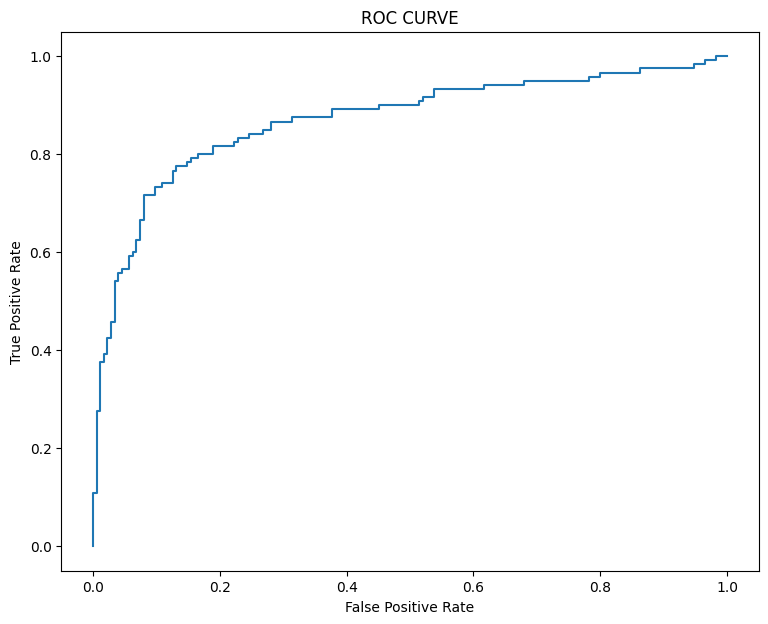

In [150]:
from sklearn.metrics import roc_curve , auc

y_score = logreg.decision_function(X_val)

FPR , TPR , _ = roc_curve(y_val , y_score)

ROC_AUC = auc(FPR , TPR)

print(ROC_AUC)

plt.figure(figsize = [9 , 7])
plt.plot(FPR , TPR)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.show()

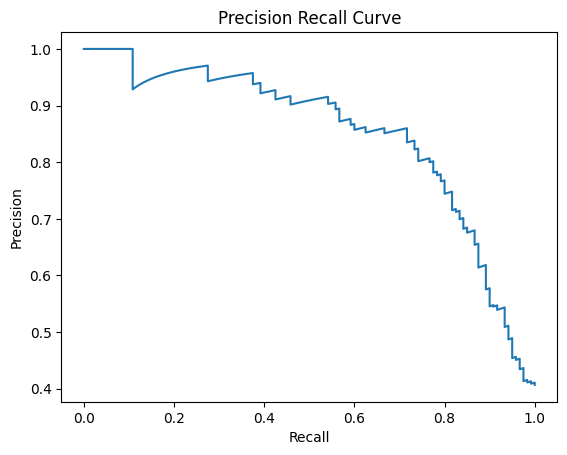

In [151]:
from sklearn.metrics import precision_recall_curve

precision , recall , _ = precision_recall_curve(y_val , y_score)
PR_AUR = auc(recall , precision)

plt.plot(recall , precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Curve')
plt.show()

In [152]:
from sklearn.model_selection import StratifiedShuffleSplit , cross_val_score
cv = StratifiedShuffleSplit(n_splits = 10 , test_size = 0.25 , random_state = 42)

columns_names = X.columns
X = st_scale.fit_transform(X)
X_test = st_scale.transform(test_df_aligned)

accuracies = cross_val_score(LogisticRegression(solver = 'liblinear') , X , y , cv = cv)

print(accuracies)
print(f"Mean : {round(accuracies.mean() , 2)}")

[0.80717489 0.81165919 0.82511211 0.78923767 0.79820628 0.84304933
 0.82959641 0.85201794 0.83408072 0.83408072]
Mean : 0.82


In [153]:
from sklearn.model_selection import GridSearchCV , StratifiedKFold

c_vals = [round(x, 2) for x in np.arange(0.2, 1.0, 0.1)] + list(range(1, 18))
penalties = ['l1' , 'l2']
cv = StratifiedShuffleSplit(n_splits = 10 , test_size = 0.25 , random_state = 42)

param = {
    'penalty' : penalties ,
    'C' : c_vals
}


grid = GridSearchCV(
    estimator = LogisticRegression(solver='liblinear', random_state=42) ,
    param_grid = param ,
    scoring = 'accuracy' ,
    n_jobs = 1 ,
    cv = cv
)

grid.fit(X , y)

GridSearchCV(cv=StratifiedShuffleSplit(n_splits=10, random_state=42, test_size=0.25,
            train_size=None),
             estimator=LogisticRegression(random_state=42, solver='liblinear'),
             n_jobs=1,
             param_grid={'C': [np.float64(0.2), np.float64(0.3),
                               np.float64(0.4), np.float64(0.5),
                               np.float64(0.6), np.float64(0.7),
                               np.float64(0.8), np.float64(0.9), 1, 2, 3, 4, 5,
                               6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
                         'penalty': ['l1', 'l2']},
             scoring='accuracy')

In [154]:
print(grid.best_score_)

0.8242152466367711


In [155]:
print(grid.best_estimator_)

LogisticRegression(C=5, random_state=42, solver='liblinear')


In [156]:
print(grid.best_params_)

{'C': 5, 'penalty': 'l2'}


In [157]:
logreg_grid = grid.best_estimator_
logreg_grid.score(X,y)

0.8428731762065096

In [158]:
test_preds = grid.predict(X_test)

In [159]:
len(X_test)

418

In [160]:
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_val shape: (295, 46)
X_test shape: (418, 46)


In [161]:
submission = pd.DataFrame({
    'PassengerId' : id ,
    'Survived': test_preds
})

In [162]:
len(submission)

418

In [163]:
submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')


Saved submission.csv
